# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramithnayak8/ML_pipeline/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Lane 2 -- Refresh / Content Opportunity Scoring.** Which page should a content editor review
first for refresh, expansion, protection, pruning, or monitoring, given that they can only get
to a fraction of the inventory each cycle?

**Decision this supports:** the ORDER a limited weekly review queue gets worked in, not a
one-off true/false verdict on any single page.

**Who acts, and how:** a content strategist works a ranked queue, choosing an action per page
from its reason codes -- refresh, expand, protect, prune, or monitor.

**Cost of a wrong call:** a false positive wastes a scarce editor-hour on a page that did not
need it; a false negative lets a real decliner keep losing visibility, unnoticed, for another
review cycle -- a cost that compounds the longer it is missed. Because a miss is more expensive
than a false alarm, the design favors not burying real decliners over being surgically precise
at the very top.

**Why data/ML helps:** the signal is spread thin across many weakly-informative, interacting
fields (confirmed in `w02_ml_task_framing.ipynb` -- the model's own top-10 feature importances
top out at 0.16 and taper gradually). No single if-statement captures that; a learned ranking
can.

In [1]:
import json

print("Lane: Refresh / Content Opportunity Scoring")
print("Unit of analysis: one content page (content_id), trailing-90-day snapshot")
print("Metric chosen to be judged on: Precision@50 (matches a ~50-page weekly review capacity)")


Lane: Refresh / Content Opportunity Scoring
Unit of analysis: one content page (content_id), trailing-90-day snapshot
Metric chosen to be judged on: Precision@50 (matches a ~50-page weekly review capacity)


## 2. Data

**Source:** the starter dataset that ships in this repo,
`data/raw/content_refresh_anonymized.csv` -- 30,000 pseudonymized pages across 32 clients, all
metrics aggregated over a trailing 90-day window ending at export time. **This capstone does
NOT use the Hugging Face warehouse release** (`FlyRank/internship-warehouse`) -- that is an
explicit, disclosed scope limitation (see section 5), not an oversight.

**Excluded, and why** (full detail: `w03_data_contract.ipynb`, `w03_feature_leakage_check.ipynb`):
`trend_direction` / `trend_pct` (the label and its raw ingredient), the six 30-day window
columns that `trend_pct` is built from, `provider_used` / `model_used` (content-generation
metadata, not a performance signal), and `content_id` / `client_id` (pseudonyms -- grouping only).

**Public safety:** every ID below is a pseudonym (`content_xxxx`, `client_xxxx`); no raw URLs,
queries, or client names appear anywhere in this notebook or its outputs.

In [2]:
import pandas as pd

raw = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
print(f"{len(raw):,} rows, {raw.shape[1]} columns, {raw['client_id'].nunique()} clients")

banned = {"trend_direction", "trend_pct", "impressions_last_30d", "clicks_last_30d",
          "sessions_last_30d", "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
          "provider_used", "model_used", "content_id", "client_id"}
print("\nExcluded columns confirmed present in the RAW file (they exist, but never become "
      "features):")
print(sorted(banned & set(raw.columns)))


30,000 rows, 44 columns, 32 clients

Excluded columns confirmed present in the RAW file (they exist, but never become features):
['clicks_last_30d', 'clicks_prev_30d', 'client_id', 'content_id', 'impressions_last_30d', 'impressions_prev_30d', 'model_used', 'provider_used', 'sessions_last_30d', 'sessions_prev_30d', 'trend_direction', 'trend_pct']


## 3. Methodology

**Label (proxy, not a future outcome):** `is_declining_label = (trend_direction == "down")`.
`trend_direction` buckets `trend_pct`, a real measured change over the CURRENT trailing window
-- so this ranks "looks weak right now," not "will decline next month"
(`w02_ml_task_framing.ipynb`).

**Features:** 18 numeric + 8 categorical raw fields (52 engineered columns after one-hot
encoding), including two flags this capstone adds beyond the reference pipeline --
`has_keyword_data` / `has_word_count` -- so missingness (which follows `content_type`, not
chance) is explicit rather than silently folded into a `fillna(0)` (`w03_feature_leakage_check.ipynb`).

**Baseline:** a transparent rule -- `stale_visible` (not updated in 180+ days, still visible),
`low_ctr_visible` (visible, well-positioned, weak CTR -- CONFIRMED in the signal audit with a
+12.6pp gap on n=9,759), and `thin_visible` (under 1,200 words, still visible). Score = count of
matching reasons + a visibility tiebreaker. No fitted weights, no label inside the formula
(`w04_baseline_score.ipynb`, `w04_signal_audit.ipynb`).

**Model:** logistic regression and random forest, chosen per the "yes/no observed label ->
readable then stronger" rule. Standardized inputs for logistic regression.

**Validation:** client-grouped 80/20 split (`GroupShuffleSplit` on `client_id`, `random_state=42`)
-- pages from one client never appear in both train and test. `w06_validation_audit.ipynb`
showed a naive random split inflates AUC by +0.146 over this honest split, and confirmed the
`trend_pct` leak survives even out-of-fold (AUC jumps to 1.000) -- so this split, and the
attack test, are load-bearing, not decorative.

In [3]:
import numpy as np

df = raw[(raw["impressions_90d"] > 0) & (raw["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)

df["has_keyword_data"] = df["search_volume"].notna().astype(int)
df["has_word_count"] = df["word_count"].notna().astype(int)
numeric_fill_zero = ["search_volume", "competition", "cpc", "word_count", "char_count",
                     "impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d",
                     "days_with_impressions", "days_with_sessions", "content_age_days",
                     "days_since_last_update", "ctr", "avg_position", "engagement_rate",
                     "scroll_rate", "ai_traffic_pct"]
for c in numeric_fill_zero:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan).fillna(0)
categorical_cols = ["competition_level", "content_type", "main_intent", "age_tier",
                    "freshness_tier", "word_count_tier", "impression_tier", "position_tier"]
for c in categorical_cols:
    df[c] = df[c].fillna("unknown").astype(str)
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

feature_cols = (["search_volume", "competition", "cpc", "word_count", "char_count",
                 "log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "log_ai_sessions_90d",
                 "days_with_impressions", "days_with_sessions", "content_age_days",
                 "days_since_last_update", "ctr", "avg_position", "engagement_rate",
                 "scroll_rate", "ai_traffic_pct", "has_keyword_data", "has_word_count"]
                + categorical_cols)

stale_visible = (df["days_since_last_update"] >= 180) & (df["impressions_90d"] >= 500)
low_ctr_visible = ((df["impressions_90d"] >= 500) & (df["avg_position"] > 0)
                   & (df["avg_position"] <= 20) & (df["ctr"] < 0.5))
thin_visible = (df["word_count"] > 0) & (df["word_count"] < 1200) & (df["impressions_90d"] >= 250)
reason_count = stale_visible.astype(int) + low_ctr_visible.astype(int) + thin_visible.astype(int)
df["rule_score"] = reason_count + 0.99 * df["impressions_90d"].rank(pct=True)

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df["is_declining_label"]
print(f"{len(df):,} rows, {len(feature_cols)} raw feature columns -> {X.shape[1]} engineered")


30,000 rows, 28 raw feature columns -> 46 engineered


## 4. Results (vs baseline)

Same held-out test rows, same metrics, for the baseline rule and both models -- honest,
client-grouped, out-of-sample.

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
overlap = len(set(df.loc[train_idx, "client_id"]) & set(df.loc[test_idx, "client_id"]))

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)
logit = LogisticRegression(max_iter=2000, random_state=42).fit(X_train_s, y_train)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42,
                             class_weight="balanced_subsample").fit(X_train, y_train)

rule_test = df.loc[test_idx, "rule_score"].values
proba_logit = logit.predict_proba(X_test_s)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"client overlap train/test: {overlap} (0 = honest)")
print(f"test base rate: {y_test.mean():.1%}\n")
for name, scores in [("baseline rule", rule_test), ("logistic_regression", proba_logit),
                      ("random_forest", proba_rf)]:
    print(f"{name:>20}: P@20={precision_at_k(scores, y_test, 20):.3f}  "
          f"P@50={precision_at_k(scores, y_test, 50):.3f}  "
          f"ROC-AUC={roc_auc_score(y_test, scores):.3f}")


client overlap train/test: 0 (0 = honest)
test base rate: 51.1%

       baseline rule: P@20=0.400  P@50=0.420  ROC-AUC=0.532
 logistic_regression: P@20=0.700  P@50=0.720  ROC-AUC=0.615
       random_forest: P@20=0.550  P@50=0.640  ROC-AUC=0.605


## 5. Limitations

- **Scope, disclosed up front:** this capstone uses only the 30,000-row starter snapshot, not
  the ~79M-row Hugging Face warehouse release. That means no multi-month history, no true
  future-window label, and a smaller, less diverse client base than the full study would allow.
  A stronger next iteration builds `prior 90 days -> next 30 days` labels from
  `fact_content_daily_performance`.
- **Proxy label.** The label describes the current window, not a future outcome (section 3).
- **Small group count.** Only 32 clients total (25 train / 7 test here) -- `w05_model.ipynb`
  found the choice of split can swing which model wins as much as the choice of algorithm does.
- **No causal claim.** Nothing here shows a refresh CAUSES recovery -- only an experiment could.
- **Cannot separate decline from consolidation or seasonality** -- no sibling-page or
  multi-period data in this slice (lane guide, section 7).
- **Numbers are library-version sensitive.** Re-running the shipped reference pipeline in this
  environment reproduced the baseline exactly but got a different random-forest number than the
  committed report (`w06_validation_audit.ipynb`) -- the stable claim is the relative lift over
  the baseline, not any single decimal.
- **Only ~10% of the final queue reaches "high" confidence** (section 6) -- most of it is a
  starting point for human judgment, not a strong signal by itself.

In [5]:
print(f"clients used: {df['client_id'].nunique()} of 32 total in the starter release")
print("warehouse release used: NO (starter CSV only -- disclosed scope limitation)")


clients used: 32 of 32 total in the starter release
warehouse release used: NO (starter CSV only -- disclosed scope limitation)


## 6. Ranked recommendations

Final score blends the validated logistic regression (60%, percentile-ranked, refit on all rows
now that validation is done) with the baseline rule (40%), matching `w07_action_playbook.ipynb`.
Reason codes: the three baseline flags plus `model_flagged_high_risk` (model probability >=
0.65). Only pages clearing a volume floor AND carrying a real reason code reach "high"
confidence.

In [6]:
logit_full = LogisticRegression(max_iter=2000, random_state=42).fit(scaler.fit_transform(X), y)
df["model_proba"] = logit_full.predict_proba(scaler.transform(X))[:, 1]
df["final_score"] = 0.6 * df["model_proba"].rank(pct=True) + 0.4 * df["rule_score"].rank(pct=True)

def reason_codes(i):
    reasons = []
    if stale_visible[i]:
        reasons.append("stale_visible")
    if low_ctr_visible[i]:
        reasons.append("low_ctr_visible")
    if thin_visible[i]:
        reasons.append("thin_visible")
    if df.loc[i, "model_proba"] >= 0.65:
        reasons.append("model_flagged_high_risk")
    return "|".join(reasons) if reasons else "general_refresh_review"

df["reason_codes"] = [reason_codes(i) for i in df.index]
df["rank"] = df["final_score"].rank(method="first", ascending=False).astype(int)

high_cut = df["final_score"].quantile(0.90)
df["confidence"] = np.where(
    (df["final_score"] >= high_cut) & (df["impressions_90d"] >= 500)
    & (df["reason_codes"] != "general_refresh_review"), "high",
    np.where(df["reason_codes"] != "general_refresh_review", "medium", "low"))

top10 = df.sort_values("rank").head(10)
print(f"confidence == high: {(df['confidence'] == 'high').sum():,} of {len(df):,} rows "
      f"({(df['confidence'] == 'high').mean():.1%})")
print(f"top-10 decline rate: {top10['is_declining_label'].mean():.1%}\n")
print(top10[["rank", "reason_codes", "confidence", "impressions_90d", "avg_position",
             "ctr"]].to_string(index=False))


confidence == high: 2,996 of 30,000 rows (10.0%)
top-10 decline rate: 90.0%

 rank                                         reason_codes confidence  impressions_90d  avg_position  ctr
    1 low_ctr_visible|thin_visible|model_flagged_high_risk       high             5271          15.2 0.00
    2 low_ctr_visible|thin_visible|model_flagged_high_risk       high             2227           9.9 0.00
    3              low_ctr_visible|model_flagged_high_risk       high           208678           9.7 0.00
    4 low_ctr_visible|thin_visible|model_flagged_high_risk       high             2484          13.3 0.04
    5              low_ctr_visible|model_flagged_high_risk       high           140079           7.6 0.01
    6              low_ctr_visible|model_flagged_high_risk       high            56363           5.9 0.01
    7              low_ctr_visible|model_flagged_high_risk       high           112434           7.2 0.01
    8              low_ctr_visible|model_flagged_high_risk       high      

## 7. Artifacts the paper embeds

Saving the queue and the headline comparison chart the deployed paper references.

wrote ..\outputs\capstone_ranked_queue.csv
wrote ..\outputs\charts\capstone_p50_comparison.png


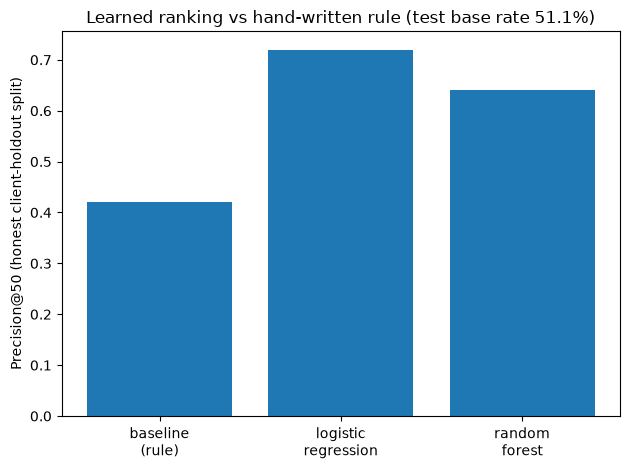

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path("../outputs")
chart_dir = out_dir / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

export_cols = ["content_id", "client_id", "rank", "final_score", "reason_codes",
               "confidence", "is_declining_label", "impressions_90d", "avg_position", "ctr"]
df[export_cols].sort_values("rank").to_csv(out_dir / "capstone_ranked_queue.csv", index=False)

fig, ax = plt.subplots()
names = ["baseline\n(rule)", "logistic\nregression", "random\nforest"]
p50_vals = [precision_at_k(rule_test, y_test, 50), precision_at_k(proba_logit, y_test, 50),
            precision_at_k(proba_rf, y_test, 50)]
ax.bar(names, p50_vals)
ax.set_ylabel("Precision@50 (honest client-holdout split)")
ax.set_title(f"Learned ranking vs hand-written rule (test base rate {y_test.mean():.1%})")
fig.tight_layout()
fig.savefig(chart_dir / "capstone_p50_comparison.png", dpi=120)
print("wrote", out_dir / "capstone_ranked_queue.csv")
print("wrote", chart_dir / "capstone_p50_comparison.png")


## ML-12 -- Demo outline, social cut, employer summary

**5-minute demo outline:**
1. The problem (30s): thousands of pages, one editor, which one first?
2. The naive answer (30s): a hand-written rule -- show it, show its Precision@50 (0.42).
3. The twist (1 min): a validated model roughly matches-to-beats it (0.64-0.72) -- but only
   when measured honestly; a naive random split would have overstated the win by 15 AUC points.
4. The leakage gut-check (1 min): show `trend_pct` collapsing the score to a suspicious 1.000 --
   why that is a red flag, not a victory.
5. The final queue (1 min): the blended ranked list, reason codes, and the honest confidence
   split (only 10% "high").
6. What's next (30s): the full warehouse, a real future-window label, a second time period.

**Social-post cut:** "A hand-written rule catches 21 of the top 50 at-risk pages. A validated
model, checked the honest way (client-holdout, not random), catches up to 36 -- and the honest
check itself was the hard part: a naive split would have made a WORSE model look 15 AUC points
better. #AppliedML #SEO"

**Employer-facing summary (3 sentences):** I built a content-refresh prioritization system on
30,000 real (anonymized) search pages: a transparent rule baseline, a validated logistic
regression / random forest comparison, and a full leakage and split-honesty audit. The audit
caught a real label leak and quantified exactly how much a dishonest split would have inflated
the result (+0.146 AUC) before it ever shipped. The final deliverable is a ranked, reason-coded
action queue with disclosed confidence levels and monitoring triggers, not just a model score.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
